
Base data range:
2017-01-31 00:00:00 -> 2025-12-29 00:00:00 | n = 2325
HORIZON = 1
TARGET_AGG = mean
TARGET_COL = target_mean_1d

========== MONTHLY_AGG = mean ==========

PCA explained variance:
  component  explained_variance_ratio
0       PC1              0.4476879691
1       PC2              0.2243201572
2       PC3              0.0915098010
3       PC4              0.0686234798
4       PC5              0.0514333881

Top loadings for PC1:
ru2y_dbp_std_20    0.3280145693
ru3m_dbp_std_20    0.3242126547
moex_range         0.3222287374
ru10y_dbp_std_20   0.3166423487
ru2y_d_abs_bp      0.3047936163
ru1y_d_abs_bp      0.3034088459
ru3m_d_abs_bp      0.2908297371
usd_rub_range      0.2702759487
brent_volume       0.2523948942
brent_logvol       0.2092497222
Name: PC1, dtype: float64

========== MONTHLY_AGG = last ==========

PCA explained variance:
  component  explained_variance_ratio
0       PC1              0.3723551068
1       PC2              0.1615353117
2       PC3              

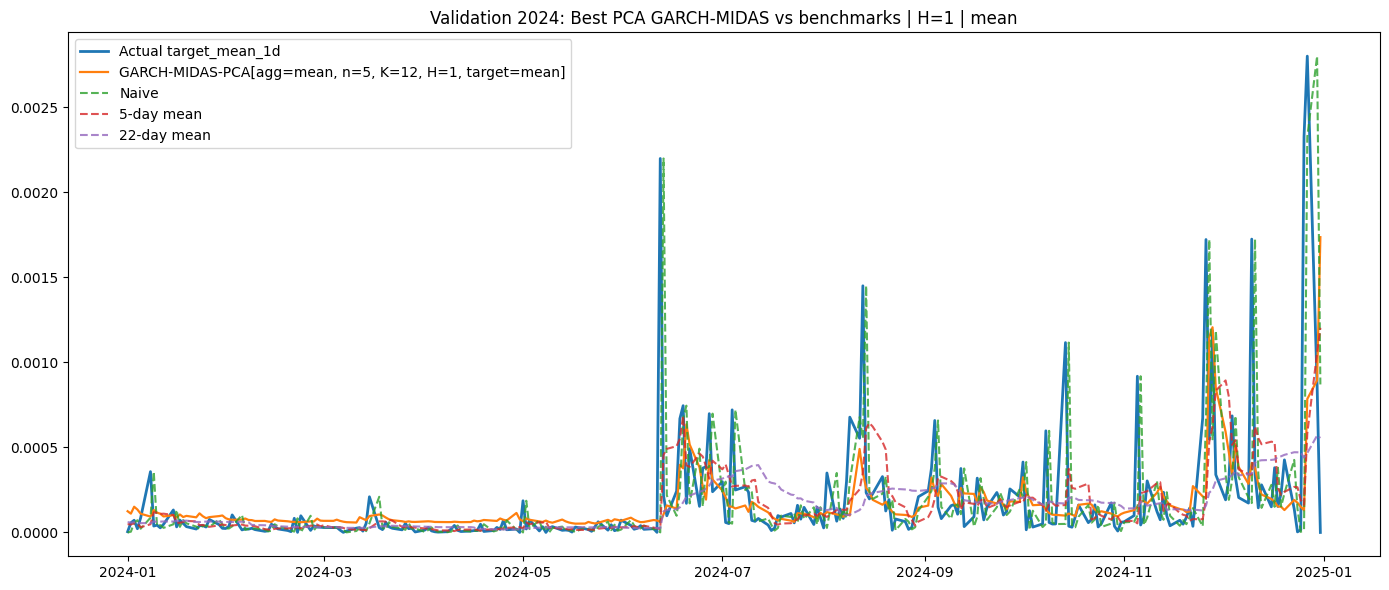

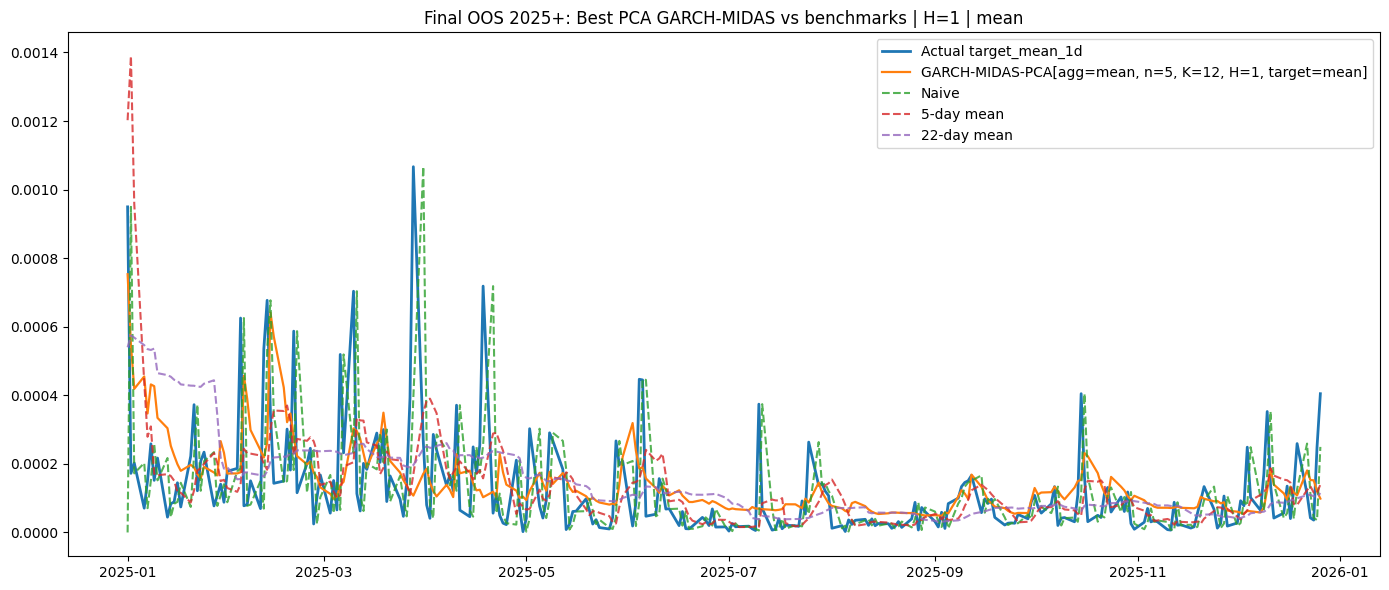

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
FILE_PATH = "/content/result_hope_8_march.xlsx"
DATE_COL = "Date"
RET_COL = "cnyrub_logret"
RV_COL = "RV_gk"

TRAIN_END = "2023-12-31"
VAL_END   = "2024-12-31"
HORIZON = 1
TARGET_AGG = "mean"

EPS = 1e-12

MACRO_COLS = [
    # "vix_level",
    # "vix_logret",
    # "usd_index_level",
    # "usd_index_logret",
    # "usd_cny_level",
    # "usd_cny_logret",
    # "usd_rub_level",
    # "usd_rub_logret",
    # "brent_level",
    # "brent_logret",
    # "moex_level",
    # "moex_logret",
    # "shibor_level",
    # "shibor_d_bp",
    # "ru_spread_10y_2y",
    # "ru_spread_10y_2y_d_bp",
    # "key_rate_rf_level",
    # "key_rate_rf_d_bp",
    # "epu_diff_ru_cn_level",
    # "epu_diff_ru_cn_log",
    "ru2y_dbp_std_20",
"ru3m_dbp_std_20",
"ru10y_dbp_std_20",
"usd_rub_range",
"moex_range",
"brent_volume",
"moex_oc",
"usd_rub_logret",
"ru2y_d_abs_bp",
"ru1y_d_abs_bp",
"ru_spread_10y_2y_d_bp",
"gsci_metal_level",
"ru2y_d_bp",
"ru1y_d_bp",
"usd_rub_level",
"ru3m_d_abs_bp",
"ru10y_dbp_ma_5",
"brent_logvol"
]

K_MONTHS_FIXED = 12

N_COMPONENTS_GRID = [ 5]
MONTHLY_AGG_GRID = ["mean", "last"]

pd.set_option("display.float_format", lambda x: f"{x:.10f}")

def load_table(file_path):
    if file_path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(file_path)

    attempts = [
        {"sep": ",", "encoding": "utf-8"},
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "utf-8-sig"},
        {"sep": ";", "encoding": "utf-8-sig"},
        {"sep": ",", "encoding": "cp1251"},
        {"sep": ";", "encoding": "cp1251"},
        {"sep": ",", "encoding": "cp1252"},
        {"sep": ";", "encoding": "cp1252"},
        {"sep": ",", "encoding": "latin1"},
        {"sep": ";", "encoding": "latin1"},
    ]

    last_error = None
    for params in attempts:
        try:
            df_ = pd.read_csv(file_path, low_memory=False, **params)
            print(f"Loaded CSV with sep={params['sep']!r}, encoding={params['encoding']!r}")
            return df_
        except Exception as e:
            last_error = e

    raise last_error

df = load_table(FILE_PATH)

df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
df = df.replace([np.inf, -np.inf], np.nan)

for col in [RET_COL, RV_COL] + MACRO_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

available_macros = [c for c in MACRO_COLS if c in df.columns]
if len(available_macros) == 0:
    raise ValueError("No macro columns from MACRO_COLS were found in the dataset.")

def make_forward_target(rv_series, horizon=5, agg="mean"):
    future_vals = pd.concat(
        [rv_series.shift(-i) for i in range(1, horizon + 1)],
        axis=1
    )
    future_vals.columns = [f"RV_t_plus_{i}" for i in range(1, horizon + 1)]

    if agg == "mean":
        target = future_vals.mean(axis=1)
    elif agg == "sum":
        target = future_vals.sum(axis=1)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

    return target

TARGET_COL = f"target_{TARGET_AGG}_{HORIZON}d"
df[TARGET_COL] = make_forward_target(df[RV_COL], horizon=HORIZON, agg=TARGET_AGG)

df["har_d"] = df[RV_COL]
df["har_w"] = df[RV_COL].rolling(window=5, min_periods=5).mean()
df["har_m"] = df[RV_COL].rolling(window=22, min_periods=22).mean()

base_data = df[[DATE_COL, RET_COL, RV_COL, TARGET_COL, "har_d", "har_w", "har_m"]].copy()
base_data = base_data.dropna(subset=[RET_COL, TARGET_COL, "har_d", "har_w", "har_m"]).reset_index(drop=True)

print("\nBase data range:")
print(base_data[DATE_COL].min(), "->", base_data[DATE_COL].max(), "| n =", len(base_data))
print(f"HORIZON = {HORIZON}")
print(f"TARGET_AGG = {TARGET_AGG}")
print(f"TARGET_COL = {TARGET_COL}")

def qlike(y_true, y_pred, eps=1e-12):
    y_true = np.clip(np.asarray(y_true, dtype=float), eps, None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1.0)

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), EPS, None)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "QLIKE": qlike(y_true, y_pred),
    }

def raw_diag(y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "raw_min": float(np.min(y_pred)),
        "raw_q01": float(np.quantile(y_pred, 0.01)),
        "raw_q05": float(np.quantile(y_pred, 0.05)),
        "raw_negative_count": int(np.sum(y_pred <= 0)),
        "raw_negative_share": float(np.mean(y_pred <= 0)),
    }

def beta_weights(K, w2):
    j = np.arange(1, K + 1, dtype=float)
    x = j / K
    w = (1.0 - x + 1e-12) ** (w2 - 1.0)
    w = w / np.sum(w)
    return w

def transform_ab(u1, u2):
    e1 = np.exp(u1)
    e2 = np.exp(u2)
    denom = 1.0 + e1 + e2
    alpha = e1 / denom
    beta = e2 / denom
    return alpha, beta

def inv_transform_ab(alpha, beta):
    rest = max(1.0 - alpha - beta, 1e-8)
    u1 = np.log(alpha / rest)
    u2 = np.log(beta / rest)
    return u1, u2

def build_monthly_macro_df(df_in, macro_cols, monthly_agg="mean"):
    tmp = df_in[[DATE_COL] + macro_cols].copy()
    tmp["month"] = tmp[DATE_COL].dt.to_period("M")

    if monthly_agg == "mean":
        monthly = tmp.groupby("month")[macro_cols].mean().reset_index()
    elif monthly_agg == "last":
        monthly = tmp.groupby("month")[macro_cols].last().reset_index()
    else:
        raise ValueError("monthly_agg must be 'mean' or 'last'")

    monthly = monthly.sort_values("month").reset_index(drop=True)
    return monthly

def build_monthly_pca_factors(monthly_macro_df, scale_end_date, max_components):
    monthly = monthly_macro_df.copy().sort_values("month").reset_index(drop=True)

    feature_cols = [c for c in monthly.columns if c != "month"]
    X = monthly[feature_cols].copy()

    scale_end_period = pd.Timestamp(scale_end_date).to_period("M")
    train_mask = monthly["month"] <= scale_end_period

    X_train = X.loc[train_mask].copy()
    if len(X_train) < 24:
        return None

    train_means = X_train.mean()
    X = X.fillna(train_means)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X.loc[train_mask])
    X_all_scaled = scaler.transform(X)

    max_components = min(max_components, X_all_scaled.shape[1], X_train_scaled.shape[0])
    if max_components < 1:
        return None

    pca = PCA(n_components=max_components)
    pcs_all = pca.fit(X_train_scaled).transform(X_all_scaled)

    out = pd.DataFrame({"month": monthly["month"].values})
    for i in range(max_components):
        out[f"PC{i+1}"] = pcs_all[:, i]

    explained = pd.DataFrame({
        "component": [f"PC{i+1}" for i in range(max_components)],
        "explained_variance_ratio": pca.explained_variance_ratio_
    })

    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_cols,
        columns=[f"PC{i+1}" for i in range(max_components)]
    )

    return {
        "monthly_pca_df": out,
        "explained_variance": explained,
        "loadings": loadings,
        "scaler": scaler,
        "pca": pca,
        "feature_cols": feature_cols
    }
def prepare_garch_midas_pca_dataset(
    monthly_pca_df,
    n_components,
    K_months,
    scale_end_date=TRAIN_END
):
    pc_cols = [f"PC{i}" for i in range(1, n_components + 1)]
    for c in pc_cols:
        if c not in monthly_pca_df.columns:
            return None

    monthly = monthly_pca_df[["month"] + pc_cols].copy().dropna()
    monthly = monthly.set_index("month").sort_index()

    scale_end_period = pd.Timestamp(scale_end_date).to_period("M")
    scale_sample = monthly.loc[monthly.index <= scale_end_period, pc_cols]

    if len(scale_sample) < 12:
        return None

    mu = scale_sample.mean()
    sd = scale_sample.std().replace(0, np.nan)
    if sd.isna().any():
        return None

    monthly_std = (monthly - mu) / sd
    monthly_std = monthly_std.dropna()

    data = base_data.copy()
    data["month"] = data[DATE_COL].dt.to_period("M")

    lag_matrix = []
    for current_month in data["month"]:
        row = []
        ok = True
        for lag in range(1, K_months + 1):
            lag_month = current_month - lag
            if lag_month in monthly_std.index:
                row.extend(monthly_std.loc[lag_month, pc_cols].values.tolist())
            else:
                ok = False
                break
        if ok:
            lag_matrix.append(row)
        else:
            lag_matrix.append([np.nan] * (K_months * n_components))

    lag_cols = []
    for lag in range(1, K_months + 1):
        for j in range(1, n_components + 1):
            lag_cols.append(f"PC{j}_lag_{lag}")

    lag_df = pd.DataFrame(lag_matrix, columns=lag_cols, index=data.index)

    data = pd.concat([data, lag_df], axis=1)
    data = data.dropna(subset=lag_cols).reset_index(drop=True)

    return data

def unpack_params(params, n_components):
    mu = params[0]
    u1 = params[1]
    u2 = params[2]
    m = params[3]
    thetas = np.asarray(params[4:4+n_components], dtype=float)
    raw_w2 = params[4+n_components]
    alpha, beta = transform_ab(u1, u2)
    w2 = 1.0 + np.exp(raw_w2)
    return mu, alpha, beta, m, thetas, w2

def compute_tau_multi(Z_list, m, thetas, w2):
    K = Z_list[0].shape[1]
    w = beta_weights(K, w2)

    signal = np.zeros(Z_list[0].shape[0], dtype=float)
    for j, Zj in enumerate(Z_list):
        signal += thetas[j] * (Zj @ w)

    tau = np.exp(m + signal)
    tau = np.clip(tau, EPS, None)
    return tau

def compute_g_h(returns, tau, mu, alpha, beta):
    T = len(returns)
    g = np.zeros(T)
    h = np.zeros(T)

    g[0] = 1.0
    h[0] = tau[0] * g[0]

    for t in range(1, T):
        g[t] = (
            (1.0 - alpha - beta)
            + alpha * ((returns[t - 1] - mu) ** 2 / tau[t - 1])
            + beta * g[t - 1]
        )
        g[t] = max(g[t], EPS)
        h[t] = tau[t] * g[t]

    return g, h

def make_Z_list(df_in, n_components, K_months):
    Z_list = []
    for j in range(1, n_components + 1):
        cols = [f"PC{j}_lag_{lag}" for lag in range(1, K_months + 1)]
        Zj = df_in[cols].values.astype(float)
        Z_list.append(Zj)
    return Z_list

def negloglik_garch_midas_pca(params, returns, Z_list, n_components):
    mu, alpha, beta, m, thetas, w2 = unpack_params(params, n_components)

    tau = compute_tau_multi(Z_list, m, thetas, w2)
    g, h = compute_g_h(returns, tau, mu, alpha, beta)

    if np.any(~np.isfinite(h)) or np.any(h <= 0):
        return 1e20

    ll = -0.5 * np.sum(np.log(2.0 * np.pi) + np.log(h) + ((returns - mu) ** 2) / h)

    if not np.isfinite(ll):
        return 1e20

    return -ll

def fit_garch_midas_pca(train_df, n_components, K_months):
    returns = train_df[RET_COL].values.astype(float)
    Z_list = make_Z_list(train_df, n_components, K_months)

    mu0 = np.mean(returns)
    a0, b0 = 0.05, 0.90
    u10, u20 = inv_transform_ab(a0, b0)
    m0 = np.log(np.var(returns) + EPS)
    theta0 = [0.10] * n_components
    w20 = np.log(4.0 - 1.0)

    starts = [
        np.array([mu0, u10, u20, m0] + theta0 + [w20], dtype=float),
        np.array([mu0, u10, u20, m0] + [-x for x in theta0] + [w20], dtype=float),
        np.array([0.0, u10, u20, m0] + theta0 + [np.log(2.0)], dtype=float),
    ]

    best_res = None
    best_fun = np.inf

    for x0 in starts:
        try:
            res = minimize(
                negloglik_garch_midas_pca,
                x0=x0,
                args=(returns, Z_list, n_components),
                method="L-BFGS-B",
                options={"maxiter": 1500}
            )
            if res.success and np.isfinite(res.fun) and res.fun < best_fun:
                best_fun = res.fun
                best_res = res
        except Exception:
            continue

    if best_res is None:
        return None

    n = len(returns)
    k = len(best_res.x)
    nll = best_res.fun
    aic = 2 * k + 2 * nll
    bic = np.log(n) * k + 2 * nll

    return {
        "params": best_res.x,
        "success": best_res.success,
        "nll": nll,
        "aic": aic,
        "bic": bic,
        "opt_result": best_res,
    }

def aggregate_hstep_variance(h_vec, agg="mean"):
    h_vec = np.asarray(h_vec, dtype=float)

    if agg == "mean":
        return np.mean(h_vec)
    elif agg == "sum":
        return np.sum(h_vec)
    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

def forecast_horizon_series_pca(full_prepared_df, fit_params, n_components, K_months, horizon=5, agg="mean"):

    returns = full_prepared_df[RET_COL].values.astype(float)
    Z_list = make_Z_list(full_prepared_df, n_components, K_months)

    mu, alpha, beta, m, thetas, w2 = unpack_params(fit_params, n_components)

    tau = compute_tau_multi(Z_list, m, thetas, w2)
    g, h = compute_g_h(returns, tau, mu, alpha, beta)

    pred = np.full(len(full_prepared_df), np.nan)

    max_t = len(full_prepared_df) - horizon
    for t in range(max_t):
        g_prev = (
            (1.0 - alpha - beta)
            + alpha * ((returns[t] - mu) ** 2 / tau[t])
            + beta * g[t]
        )
        g_prev = max(g_prev, EPS)

        h_path = []
        h_1 = tau[t + 1] * g_prev
        h_path.append(h_1)

        g_future = g_prev
        for s in range(2, horizon + 1):
            g_future = (1.0 - alpha - beta) + (alpha + beta) * g_future
            g_future = max(g_future, EPS)

            h_future = tau[t + s] * g_future
            h_path.append(h_future)

        pred[t] = aggregate_hstep_variance(h_path, agg=agg)

    out = full_prepared_df[[DATE_COL, TARGET_COL, "har_d", "har_w", "har_m"]].copy()
    out["pred_garch_midas_pca"] = pred
    return out

search_rows = []

max_requested_components = max(N_COMPONENTS_GRID)

for monthly_agg in MONTHLY_AGG_GRID:
    print(f"\n========== MONTHLY_AGG = {monthly_agg} ==========")

    monthly_macro_df = build_monthly_macro_df(
        df_in=df,
        macro_cols=available_macros,
        monthly_agg=monthly_agg
    )

    pca_obj_train = build_monthly_pca_factors(
        monthly_macro_df=monthly_macro_df,
        scale_end_date=TRAIN_END,
        max_components=max_requested_components
    )

    if pca_obj_train is None:
        print(f"Skipping agg={monthly_agg}: PCA construction failed.")
        continue

    monthly_pca_train_df = pca_obj_train["monthly_pca_df"]
    explained_train_df = pca_obj_train["explained_variance"]
    loadings_train_df = pca_obj_train["loadings"]

    print("\nPCA explained variance:")
    print(explained_train_df)

    print("\nTop loadings for PC1:")
    if "PC1" in loadings_train_df.columns:
        print(loadings_train_df["PC1"].sort_values(key=np.abs, ascending=False).head(10))

    for n_components in N_COMPONENTS_GRID:
        if f"PC{n_components}" not in monthly_pca_train_df.columns:
            continue

        prepared = prepare_garch_midas_pca_dataset(
            monthly_pca_df=monthly_pca_train_df,
            n_components=n_components,
            K_months=K_MONTHS_FIXED,
            scale_end_date=TRAIN_END
        )

        if prepared is None or len(prepared) < 500:
            continue

        train_df = prepared[prepared[DATE_COL] <= TRAIN_END].copy()
        val_df = prepared[(prepared[DATE_COL] > TRAIN_END) & (prepared[DATE_COL] <= VAL_END)].copy()

        if len(train_df) < 500 or len(val_df) < 30:
            continue

        fit_obj = fit_garch_midas_pca(train_df, n_components, K_MONTHS_FIXED)
        if fit_obj is None:
            continue

        pred_df = forecast_horizon_series_pca(
            full_prepared_df=prepared,
            fit_params=fit_obj["params"],
            n_components=n_components,
            K_months=K_MONTHS_FIXED,
            horizon=HORIZON,
            agg=TARGET_AGG
        )

        val_eval = pred_df[(pred_df[DATE_COL] > TRAIN_END) & (pred_df[DATE_COL] <= VAL_END)].copy()
        val_eval = val_eval.dropna(subset=["pred_garch_midas_pca", TARGET_COL])

        if len(val_eval) == 0:
            continue

        mets = calc_metrics(val_eval[TARGET_COL].values, val_eval["pred_garch_midas_pca"].values)
        di = raw_diag(val_eval["pred_garch_midas_pca"].values)

        explained_share = explained_train_df.iloc[:n_components]["explained_variance_ratio"].sum()

        search_rows.append({
            "monthly_agg": monthly_agg,
            "n_components": n_components,
            "K_months": K_MONTHS_FIXED,
            "HORIZON": HORIZON,
            "TARGET_AGG": TARGET_AGG,
            "explained_share_train": explained_share,
            "AIC_train": fit_obj["aic"],
            "BIC_train": fit_obj["bic"],
            "val_MAE": mets["MAE"],
            "val_RMSE": mets["RMSE"],
            "val_MSE": mets["MSE"],
            "val_QLIKE": mets["QLIKE"],
            **di
        })

search_df = pd.DataFrame(search_rows)

if len(search_df) == 0:
    raise ValueError("No valid PCA GARCH-MIDAS specification was estimated.")

search_df = search_df.sort_values(["val_QLIKE", "val_RMSE", "BIC_train"]).reset_index(drop=True)

print("\n========== PCA GARCH-MIDAS VALIDATION SEARCH ==========")
print(search_df.round({
    "explained_share_train": 6,
    "AIC_train": 4,
    "BIC_train": 4,
    "val_MAE": 10,
    "val_RMSE": 10,
    "val_MSE": 10,
    "val_QLIKE": 6,
    "raw_min": 10,
    "raw_q01": 10,
    "raw_q05": 10,
    "raw_negative_share": 6
}))

best = search_df.iloc[0].to_dict()
print("\n========== BEST PCA GARCH-MIDAS CONFIG ==========")
print(best)

best_agg = best["monthly_agg"]
best_n = int(best["n_components"])
best_K = int(best["K_months"])

best_monthly_macro_df = build_monthly_macro_df(
    df_in=df,
    macro_cols=available_macros,
    monthly_agg=best_agg
)

pca_obj_train_best = build_monthly_pca_factors(
    monthly_macro_df=best_monthly_macro_df,
    scale_end_date=TRAIN_END,
    max_components=max_requested_components
)
if pca_obj_train_best is None:
    raise ValueError("PCA refit through TRAIN_END failed.")

monthly_pca_train_best_df = pca_obj_train_best["monthly_pca_df"]
explained_train_best_df = pca_obj_train_best["explained_variance"]
loadings_train_best_df = pca_obj_train_best["loadings"]

prepared_val = prepare_garch_midas_pca_dataset(
    monthly_pca_df=monthly_pca_train_best_df,
    n_components=best_n,
    K_months=best_K,
    scale_end_date=TRAIN_END
)

fit_val = fit_garch_midas_pca(
    train_df=prepared_val[prepared_val[DATE_COL] <= TRAIN_END].copy(),
    n_components=best_n,
    K_months=best_K
)

pred_val_df = forecast_horizon_series_pca(
    full_prepared_df=prepared_val,
    fit_params=fit_val["params"],
    n_components=best_n,
    K_months=best_K,
    horizon=HORIZON,
    agg=TARGET_AGG
)

val_eval = pred_val_df[
    (pred_val_df[DATE_COL] > TRAIN_END) & (pred_val_df[DATE_COL] <= VAL_END)
].copy()
val_eval = val_eval.dropna(subset=["pred_garch_midas_pca", TARGET_COL])

print("\n========== BEST MODEL PCA EXPLAINED VARIANCE (TRAIN FIT) ==========")
print(explained_train_best_df)

print("\n========== BEST MODEL TOP LOADINGS FOR PC1 ==========")
if "PC1" in loadings_train_best_df.columns:
    print(loadings_train_best_df["PC1"].sort_values(key=np.abs, ascending=False).head(10))

pca_obj_full_pre_oos = build_monthly_pca_factors(
    monthly_macro_df=best_monthly_macro_df,
    scale_end_date=VAL_END,
    max_components=max_requested_components
)
if pca_obj_full_pre_oos is None:
    raise ValueError("PCA refit through VAL_END failed.")

monthly_pca_full_pre_oos_df = pca_obj_full_pre_oos["monthly_pca_df"]

prepared_oos = prepare_garch_midas_pca_dataset(
    monthly_pca_df=monthly_pca_full_pre_oos_df,
    n_components=best_n,
    K_months=best_K,
    scale_end_date=VAL_END
)

fit_oos = fit_garch_midas_pca(
    train_df=prepared_oos[prepared_oos[DATE_COL] <= VAL_END].copy(),
    n_components=best_n,
    K_months=best_K
)

pred_oos_df = forecast_horizon_series_pca(
    full_prepared_df=prepared_oos,
    fit_params=fit_oos["params"],
    n_components=best_n,
    K_months=best_K,
    horizon=HORIZON,
    agg=TARGET_AGG
)

oos_eval = pred_oos_df[pred_oos_df[DATE_COL] > VAL_END].copy()
oos_eval = oos_eval.dropna(subset=["pred_garch_midas_pca", TARGET_COL])

def add_benchmarks(df_part, horizon, agg):
    df_part = df_part.copy()

    if agg == "mean":
        df_part["pred_naive"] = np.clip(df_part["har_d"], EPS, None)
        df_part["pred_mean5"] = np.clip(df_part["har_w"], EPS, None)
        df_part["pred_mean22"] = np.clip(df_part["har_m"], EPS, None)

    elif agg == "sum":
        df_part["pred_naive"] = np.clip(horizon * df_part["har_d"], EPS, None)
        df_part["pred_mean5"] = np.clip(horizon * df_part["har_w"], EPS, None)
        df_part["pred_mean22"] = np.clip(horizon * df_part["har_m"], EPS, None)

    else:
        raise ValueError("agg must be either 'mean' or 'sum'")

    df_part["pred_garch_midas_pca"] = np.clip(df_part["pred_garch_midas_pca"], EPS, None)
    return df_part

val_eval = add_benchmarks(val_eval, HORIZON, TARGET_AGG)
oos_eval = add_benchmarks(oos_eval, HORIZON, TARGET_AGG)

comparison_rows = []

model_name_best = f"GARCH-MIDAS-PCA[agg={best_agg}, n={best_n}, K={best_K}, H={HORIZON}, target={TARGET_AGG}]"

for set_name, part in [
    ("validation_2024", val_eval),
    ("final_oos_2025_plus", oos_eval),
]:
    y_true = part[TARGET_COL].values

    comparison_rows.append({
        "set": set_name,
        "model": model_name_best,
        **calc_metrics(y_true, part["pred_garch_midas_pca"].values),
        **raw_diag(part["pred_garch_midas_pca"].values)
    })
    comparison_rows.append({
        "set": set_name,
        "model": f"Naive | H={HORIZON} | {TARGET_AGG}",
        **calc_metrics(y_true, part["pred_naive"].values),
        **raw_diag(part["pred_naive"].values)
    })
    comparison_rows.append({
        "set": set_name,
        "model": f"5-day mean | H={HORIZON} | {TARGET_AGG}",
        **calc_metrics(y_true, part["pred_mean5"].values),
        **raw_diag(part["pred_mean5"].values)
    })
    comparison_rows.append({
        "set": set_name,
        "model": f"22-day mean | H={HORIZON} | {TARGET_AGG}",
        **calc_metrics(y_true, part["pred_mean22"].values),
        **raw_diag(part["pred_mean22"].values)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[[
    "set", "model", "MAE", "RMSE", "MSE", "QLIKE",
    "raw_min", "raw_q01", "raw_q05", "raw_negative_count", "raw_negative_share"
]]
comparison_df = comparison_df.sort_values(["set", "QLIKE", "RMSE"]).reset_index(drop=True)

print("\n========== BEST PCA GARCH-MIDAS VS BENCHMARKS ==========")
print(comparison_df.round({
    "MAE": 10,
    "RMSE": 10,
    "MSE": 10,
    "QLIKE": 6,
    "raw_min": 10,
    "raw_q01": 10,
    "raw_q05": 10,
    "raw_negative_share": 6
}))

comparison_pivot = comparison_df.pivot(
    index="model",
    columns="set",
    values=["MAE", "RMSE", "QLIKE", "raw_negative_count"]
)

print("\n========== PIVOT TABLE ==========")
print(comparison_pivot.round(10))

suffix = f"H{HORIZON}_{TARGET_AGG}"

search_df.to_csv(f"garch_midas_pca_search_{suffix}.csv", index=False)
comparison_df.to_csv(f"garch_midas_pca_best_vs_benchmarks_{suffix}.csv", index=False)
comparison_pivot.to_csv(f"garch_midas_pca_best_vs_benchmarks_{suffix}_pivot.csv")

explained_train_best_df.to_csv(f"garch_midas_pca_explained_variance_train_{suffix}.csv", index=False)
loadings_train_best_df.to_csv(f"garch_midas_pca_loadings_train_{suffix}.csv")

val_out = val_eval[[DATE_COL, TARGET_COL, "pred_garch_midas_pca", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
val_out["set"] = "validation_2024"

oos_out = oos_eval[[DATE_COL, TARGET_COL, "pred_garch_midas_pca", "pred_naive", "pred_mean5", "pred_mean22"]].copy()
oos_out["set"] = "final_oos_2025_plus"

all_preds = pd.concat([val_out, oos_out], axis=0).reset_index(drop=True)
all_preds.to_csv(f"garch_midas_pca_predictions_{suffix}.csv", index=False)

print("\nSaved files:")
print(f"- garch_midas_pca_search_{suffix}.csv")
print(f"- garch_midas_pca_best_vs_benchmarks_{suffix}.csv")
print(f"- garch_midas_pca_best_vs_benchmarks_{suffix}_pivot.csv")
print(f"- garch_midas_pca_explained_variance_train_{suffix}.csv")
print(f"- garch_midas_pca_loadings_train_{suffix}.csv")
print(f"- garch_midas_pca_predictions_{suffix}.csv")

def plot_preds(df_part, title):
    plt.figure(figsize=(14, 6))
    plt.plot(df_part[DATE_COL], df_part[TARGET_COL], label=f"Actual {TARGET_COL}", linewidth=2)
    plt.plot(
        df_part[DATE_COL],
        df_part["pred_garch_midas_pca"],
        label=model_name_best,
        linewidth=1.6
    )
    plt.plot(df_part[DATE_COL], df_part["pred_naive"], label="Naive", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean5"], label="5-day mean", linestyle="--", alpha=0.8)
    plt.plot(df_part[DATE_COL], df_part["pred_mean22"], label="22-day mean", linestyle="--", alpha=0.8)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_preds(val_eval, f"Validation 2024: Best PCA GARCH-MIDAS vs benchmarks | H={HORIZON} | {TARGET_AGG}")
plot_preds(oos_eval, f"Final OOS 2025+: Best PCA GARCH-MIDAS vs benchmarks | H={HORIZON} | {TARGET_AGG}")